# Navier-Stokes Numerical Solution via *Chorin's Projection Method*:

#### By Paul Robert Andreini
#### 26 March 2026

**© 2026 Paul Robert Andreini. All rights reserved.** No part of this repository — including its code, derived works, or output files (e.g., `.png` images or videos created from them) — may be reproduced, distributed, or used without explicit written permission from the author.

Below, we state the two conditions for the Navier-Stokes equations of fluid dynamics:
\begin{align}
    \frac{\partial\mathbf{u}}{\partial t} + (\mathbf{u}\bullet\boldsymbol{\nabla})\mathbf{u} &= \nu\,\nabla^{2}\mathbf{u} - \frac{1}{\rho}(\boldsymbol{\nabla}\!P + \mathbf{F}_{\!\text{G}})\,;
    \tag{1}\\
    \mathbf{\boldsymbol{\nabla}\bullet u} &= 0\,.
    \tag{2}
\end{align}
In Eq. 1, $\mathbf{u}\equiv\mathbf{u}(\mathbf{x})$ is the velocity vector field; $\rho\equiv\rho(\mathbf{x})$ is the density scalar field; $P\equiv P(\mathbf{x})$ is the pressure scalar field; $\nu$ is the kinematic viscosity; and $\mathbf{F}_{\!\text{G}}$ is the force of gravity (a "source-term" that pulls the heavy fluid down). Eq. 2 states that the divergence of the velocity vector field is zero everywhere, which we require for incompressible flow.

## Method of Solution: ***Chorin's Projection Method***
[Chorin's Projection Method](https://en.wikipedia.org/wiki/Projection_method_(fluid_dynamics)#Chorin's_projection_method), as explained on Wikipedia.

#### Background:
Consider a vector field, $\mathbf{u}$. We split it into two parts: one with ***zero divergence*** (solenoidal-part, $\mathbf{u}_{\text{sol}}$) and one with ***zero curl*** (irrotational-part, $\mathbf{u}_{\text{irr}}$); that is:
\begin{align}
    \mathbf{u} &= \mathbf{u}_{\text{sol}} + \mathbf{u}_{\text{irr}}\,.
    \tag{3}
\end{align}
Notice that, since we defined $\mathbf{u}_{\text{irr}}$ by the condition that:
\begin{align}
    \boldsymbol{\nabla}\times\mathbf{u}_{\text{irr}} &= 0\,,
    \tag{4}
\end{align}
we know (so long as the domain is [simply-connected](https://en.wikipedia.org/wiki/Simply_connected_space); this will always be true for our simulation) there must exist a scalar function, $\phi\equiv\phi(\mathbf{x})$, such that:
\begin{align}
    \mathbf{u}_{\text{irr}} &= \boldsymbol{\nabla}\phi\,.
    \tag{5}
\end{align}
Then, by combining Eqs. 3,5, we can write down:
\begin{align}
    \implies \mathbf{u} &= \mathbf{u}_{\text{sol}} + \boldsymbol{\nabla}\phi\,.
    \tag{6}
\end{align}
Finally, to extract the divergence-free part, merely rearrange Eq. 6:
\begin{align}
    \implies \mathbf{u}_{\text{sol}} &= \mathbf{u} - \boldsymbol{\nabla}\phi\,.
    \tag{7}
\end{align}

#### Projection Method:
The essence of the projection method is to split a time-step update ($\mathbf{u}_{n} \to \mathbf{u}_{n+1}$) into two sub-steps:
1. First, compute an "intermediate velocity" vector field, $\mathbf{u}_{n}^{*}$, from Eq. 1, ***ignoring*** the pressure-gradient.
2. Correct the intermediate velocity using the pressure-gradient for the ***next*** time-step.

Although this might appear straightforward, actually performing these calculations can be a bit tricky...

For now, suppose we define: $\Delta\mathbf{u}_{n}' := \mathbf{u}_{n}^{*} - \mathbf{u}_{n}$ and $\Delta\mathbf{u}_{n}'' := \mathbf{u}_{n+1} - \mathbf{u}_{n}^{*}$. That is, to get from our initial velocity vector-field, $\mathbf{u}_{n}$, to the intermediate field, $\mathbf{u}_{n}^{*}$, add $\Delta\mathbf{u}_{n}'$; similarly, to get from the intermediate field to the final vector-field, $\mathbf{u}_{n+1}$, add $\Delta\mathbf{u}_{n}''$.

It can be shown (from *Wikipedia* Chorin-projection article at the top of this cell; just rearrange terms a bit) that we have for part "1.":
\begin{align}
    \Delta\mathbf{u}_{n}' &= \Delta t\cdot\Big[ \nu\nabla^{2}\mathbf{u}_{n} - \big( \mathbf{u}_{n}\bullet\boldsymbol{\nabla} \big)\mathbf{u}_{n} \Big]\,.
    \tag{8}
\end{align}
For part "2.", we have:
\begin{align}
    \Delta\mathbf{u}_{n}'' &= -\frac{\Delta t}{\rho}\cdot\boldsymbol{\nabla}P_{n+1}\,.
    \tag{9}
\end{align}
Note that the solution to Eq. 9 requires knowledge of $P_{n+1}$ while the algorithm is still at time-step $n$. To determine this, solve the Poisson Equation (using Gauss-Seidel method):
\begin{align}
    \nabla^{2}P_{n+1} &= \frac{\rho}{\Delta t}\cdot\big( \boldsymbol{\nabla}\bullet\mathbf{u}_{n}^{*} \big)\,.
    \tag{10}
\end{align}

Finally, note that, in Eq. 8, we have shown (separately) that, in the 2D case, we have:
\begin{align}
    \big[ (\mathbf{u}\bullet\boldsymbol{\nabla})\mathbf{u} \big]_{x} &= u_{x}\partial_{x}u_{x} + u_{y}\partial_{y}u_{x}\,;
    \tag{11}\\
    \big[ (\mathbf{u}\bullet\boldsymbol{\nabla})\mathbf{u} \big]_{y} &= u_{x}\partial_{x}u_{y} + u_{y}\partial_{y}u_{y}\,;
    \tag{12}\\
    \big[ \nabla^{2}\mathbf{u}_{n} \big]_{x} &= \partial_{x}^{2}u_{x} + \partial_{y}^{2}u_{x}\,;
    \tag{13}\\
    \big[ \nabla^{2}\mathbf{u}_{n} \big]_{y} &= \partial_{x}^{2}u_{y} + \partial_{y}^{2}u_{y}\,,
    \tag{14}
\end{align}
where we have dropped the time-step-number subscript, $n$, so as not to make our notation too confusing. It is easy-enough to see the pattern that has established itself; one can generalize this up to 3D if one wishes to do so. However, since this simulation is designed to be viewed on a ***computer screen*** (inherently a 2-dimensional object), we will not further pursue this generalization to higher dimensions.

In [1]:
## Importing relevant packages...
from scipy.sparse.linalg import cg, LinearOperator
from scipy.fft import dctn, idctn
import matplotlib.pyplot as plt
import os.path as osp
import numpy as np
rng = np.random.default_rng(seed=42)  ## Best practice: instead of using the "global" RNG, re-create a local-variable.
import time as t  ## For timing the simulation; keeps track of computational-efficiency improvements.

done = "Done!"
print(done)

Done!


In [2]:
## Defining constant values.
DX = 1.0  ## Arbitrary units; NOTE: DX == DY by fiat (square grid).
INV_DX = 1.0 / DX
INV_2DX = 1.0 / (2.0 * DX)
INV_DX2 = 1.0 / (DX ** 2)
DT = 1e-4      ## Units: SECONDS.
ROWS = 2160    ## 4K height.
COLS = 3840    ## 4K width.
G = 9.81       ## Surface-gravity of Earth (units are m/s^2).
NU = 2.5e-4    ## Kinematic viscosity.
LO_RHO = 0.25  ## "min" density, units arbitrary (say, kg m^-2).
HI_RHO = 1.00  ## "max" density, units arbitrary (say, kg m^-2).
N_HYDRO = 9e3  ## Number of iterations for overall hydrodynamic simulation.

print(done)

Done!


In [3]:
## Defining useful STATIC functions:

## Prints the elapsed time between two temporal-points (millisecond-resolution).
def time_printer(st: float, en: float, op=None) -> None:
    if op:
        op = op[:1].upper() + op[1:].lower()
    else:
        op = "Operation"

    delta = en - st  ## total time interval in seconds
    num_hrs = int(delta / 3600)  ## total number of hours (=3600sec) <= delta seconds
    rem_hrs = delta % 3600  ## total number of seconds remaining after hours are deducted
    num_min = int(rem_hrs / 60)  ## total number of minutes (=60sec) <= rem_hr seconds
    num_sec = np.round(rem_hrs % 60, 3)  ## total number of seconds remaining after minutes are deducted.

    hours = "hours"
    minutes = "minutes"
    seconds = "seconds"
    if num_hrs == 1:
        hours = "hour"
    if num_min == 1:
        minutes = "minute"
    if num_sec == 1:
        seconds = "second"

    print(f"{op} complete in: {num_hrs} {hours}, {num_min} {minutes}, {num_sec} {seconds}.")

####################

## Defining "helper-functions" to evaluate the gradient of a vector field in either the x- or y-directions:
##  NOTE: X is HORIZONTAL; Y is VERTICAL. We're using traditional (xy)-axes, not (rc)-axes, as is common in code.
def grad_x(vf):
    out = np.empty_like(vf)  ## Pre-allocating the output.
    out[:, 1:-1] = (vf[:, 2:] - vf[:, :-2]) * INV_2DX  ## central diff along cols
    out[:, 0]    = (vf[:, 1] - vf[:, 0]) * INV_DX      ## forward diff at left edge
    out[:, -1]   = (vf[:, -1] - vf[:, -2]) * INV_DX    ## backward diff at right edge
    return out

def grad_y(vf):
    out = np.empty_like(vf)
    ## NEGATING the differences to preserve y-UP, even though the "row" increases going DOWN.
    out[1:-1, :] = -(vf[2:, :] - vf[:-2, :]) * INV_2DX  ## central diff along rows
    out[0, :]    = -(vf[1, :] - vf[0, :]) * INV_DX      ## forward diff at top edge
    out[-1, :]   = -(vf[-1, :] - vf[-2, :]) * INV_DX    ## backward diff at bottom edge
    return out

## DENSITY advection.
def advect_semi_lagrangian(field: np.ndarray,
                           ux: np.ndarray,
                           uy: np.ndarray,
                           dt: float,
                           dx: float) -> np.ndarray:
    """
       Semi-Lagrangian advection with bicubic interpolation.

       Back-traces each grid point through the velocity field by one timestep,
        then uses a Catmull-Rom (cubic) interpolant at the departure point.

       Significantly less diffusive than bilinear while remaining unconditionally stable.

       PARAMETERS:
        field : 2-D array to be advected (e.g., density or a velocity component);
        ux    : x-velocity (positive → increasing column index);
        uy    : y-velocity (positive → up, i.e., DECREASING row index);
        dt    : timestep;
        dx    : grid spacing.
    """
    n_rows, n_cols = field.shape

    ## Build grid of cell-center coordinates (row, col).
    r_idx, c_idx = np.meshgrid(
        np.arange(n_rows, dtype=np.float64),
        np.arange(n_cols, dtype=np.float64),
        indexing="ij",
    )

    ## Back-trace: departure point in grid-index space.
    dep_c = c_idx - (ux * dt / dx)
    dep_r = r_idx + (uy * dt / dx)

    ## Clamp to domain (enforces zero-gradient BCs at walls).
    dep_r = np.clip(dep_r, 0.0, n_rows - 1.0)
    dep_c = np.clip(dep_c, 0.0, n_cols - 1.0)

    ## Integer and fractional parts.
    r0 = np.floor(dep_r).astype(int)
    c0 = np.floor(dep_c).astype(int)
    dr = dep_r - r0  ## fractional row offset in [0, 1)
    dc = dep_c - c0  ## fractional col offset in [0, 1)

    ## Four row/col indices needed for the 4x4 Catmull-Rom stencil.
    rm1 = np.clip(r0 - 1, 0, n_rows - 1)
    r1  = np.clip(r0 + 1, 0, n_rows - 1)
    r2  = np.clip(r0 + 2, 0, n_rows - 1)

    cm1 = np.clip(c0 - 1, 0, n_cols - 1)
    c1  = np.clip(c0 + 1, 0, n_cols - 1)
    c2  = np.clip(c0 + 2, 0, n_cols - 1)

    ## Catmull-Rom basis weights for parameter t in [0, 1]:
    ##   w(-1) = -0.5t^3 + t^2 - 0.5t
    ##   w( 0) =  1.5t^3 - 2.5t^2 + 1
    ##   w(+1) = -1.5t^3 + 2t^2 + 0.5t
    ##   w(+2) =  0.5t^3 - 0.5t^2
    def _catmull_rom_weights(tt):
        tt2 = tt * tt
        tt3 = tt2 * tt
        wm1 = -0.5 * tt3 + tt2 - 0.5 * tt
        w0  =  1.5 * tt3 - 2.5 * tt2 + 1.0
        w1  = -1.5 * tt3 + 2.0 * tt2 + 0.5 * tt
        w2  =  0.5 * tt3 - 0.5 * tt2
        return wm1, w0, w1, w2

    wr_m1, wr_0, wr_1, wr_2 = _catmull_rom_weights(dr)  ## row weights
    wc_m1, wc_0, wc_1, wc_2 = _catmull_rom_weights(dc)  ## col weights

    ## Gather the 4x4 neighborhood values and contract along columns first, then rows.
    ## Each row_indices x col_indices fetch is shape (n_rows, n_cols).
    row_indices = (rm1, r0, r1, r2)
    col_indices = (cm1, c0, c1, c2)
    col_weights = (wc_m1, wc_0, wc_1, wc_2)
    row_weights = (wr_m1, wr_0, wr_1, wr_2)

    out = np.zeros_like(field)
    for ri, rw in zip(row_indices, row_weights):
        row_contrib = np.zeros_like(field)
        for ci, cw in zip(col_indices, col_weights):
            row_contrib += field[ri, ci] * cw
        out += rw * row_contrib

    return out

####################

## Defining an "internal function" to be used in calculating the Laplacian (diffusion-term).
def _laplacian_stencil(vf: np.ndarray) -> np.ndarray:
    """
       Computes ∇²(vf) on the interior of vector-field (vf), considering cell side-length (dx), using pure-numpy.
        Returns an array of the same shape as vf with von Neumann (zero‑gradient) values at the four edges.
    """
    ## Pre-allocating the output: a numpy.ndarray().
    out = np.empty_like(vf, dtype=np.float64)

    ##### CALCULATING "RAW" LAPLACIAN #####

    ## Interior (everything except edges/corners).
    out[1:-1, 1:-1] = (
        vf[:-2, 1:-1] +   ## Adding contribution from cell ABOVE vf[j, k].
        vf[2:,  1:-1] +   ## Adding contribution from cell BELOW vf[j, k].
        vf[1:-1, :-2] +   ## Adding contribution from cell LEFT  OF vf[j, k].
        vf[1:-1, 2:]  -   ## Adding contribution from cell RIGHT OF vf[j, k].
        4.0 * vf[1:-1, 1:-1]  ## Subtracting contribution from cell vf[j, k] (once for each addition ==> 4 times).
    ) * INV_DX2

    ##### APPLYING VON NEUMANN BOUNDARY CONDITIONS #####

    ## Top row (row 0): ghost above = vf[0, :], so vf[-1,j] → vf[0,j].
    out[0, 1:-1] = (
        vf[0, 1:-1] +  ## ghost above (= vf[0])
        vf[1, 1:-1] +  ## below
        vf[0, :-2] +   ## left
        vf[0, 2:] -    ## right
        4.0 * vf[0, 1:-1]
    ) * INV_DX2

    ## Bottom row (row -1): ghost below = vf[-1, :], so vf[ROWS,j] → vf[-1,j]
    out[-1, 1:-1] = (
        vf[-2, 1:-1] +  ## above
        vf[-1, 1:-1] +  ## ghost below (= vf[-1])
        vf[-1, :-2] +   ## left
        vf[-1, 2:] -    ## right
        4.0 * vf[-1, 1:-1]
    ) * INV_DX2

    ## Left column (col 0): ghost left = vf[:, 0]
    out[1:-1, 0] = (
        vf[:-2, 0] +    ## above
        vf[2:, 0] +     ## below
        vf[1:-1, 0] +   ## ghost left (= vf[:,0])
        vf[1:-1, 1] -   ## right
        4.0 * vf[1:-1, 0]
    ) * INV_DX2

    ## Right column (col -1): ghost right = vf[:, -1]
    out[1:-1, -1] = (
        vf[:-2, -1] +   ## above
        vf[2:, -1] +    ## below
        vf[1:-1, -2] +  ## left
        vf[1:-1, -1] -  ## ghost right (= vf[:,-1])
        4.0 * vf[1:-1, -1]
    ) * INV_DX2

    ## Top-left corner (row 0, col 0): ghost above + ghost left
    out[0, 0] = (
        vf[0, 0] +  ## ghost above
        vf[1, 0] +  ## below
        vf[0, 0] +  ## ghost left
        vf[0, 1] -  ## right
        4.0 * vf[0, 0]
    ) * INV_DX2

    ## Top-right corner (row 0, col -1): ghost above + ghost right
    out[0, -1] = (
        vf[0, -1] +  ## ghost above
        vf[1, -1] +  ## below
        vf[0, -2] +  ## left
        vf[0, -1] -  ## ghost right
        4.0 * vf[0, -1]
    ) * INV_DX2

    ## Bottom-left corner (row -1, col 0): ghost below + ghost left
    out[-1, 0] = (
        vf[-2, 0] +  ## above
        vf[-1, 0] +  ## ghost below
        vf[-1, 0] +  ## ghost left
        vf[-1, 1] -  ## right
        4.0 * vf[-1, 0]
    ) * INV_DX2

    ## Bottom-right corner (row -1, col -1): ghost below + ghost right
    out[-1, -1] = (
        vf[-2, -1] +  ## above
        vf[-1, -1] +  ## ghost below
        vf[-1, -2] +  ## left
        vf[-1, -1] -  ## ghost right
        4.0 * vf[-1, -1]
    ) * INV_DX2

    return out

## A function designed to evaluate Eqs. 13,14.
def diffusion_term(ux: np.ndarray,
                   uy: np.ndarray,
                   nu: float) -> tuple[np.ndarray, np.ndarray]:
    """
       Computes ν∇²u for both velocity components, {ux, uy}, with homogeneous VON NEUMANN boundary-conditions.
        NOTE: does NOT use scipy.convolve(...); ONLY SLICING here!
    """
    ux_diffusion_update = nu * _laplacian_stencil(vf=ux)
    uy_diffusion_update = nu * _laplacian_stencil(vf=uy)

    return ux_diffusion_update, uy_diffusion_update

####################

## The "conjugate-gradient" (CG) method of solving the Laplacian in Poisson's equation. Slow, but highly-accurate.
def _apply_variable_poisson(p: np.ndarray,
                            inv_rho: np.ndarray) -> np.ndarray:
    """
       Computes  ∇·((1/ρ) ∇p)  using a consistent finite-difference stencil on a uniform grid with spacing DX
        and von Neumann (zero-gradient) BCs.

       Uses face-averaged (1/ρ) so the resulting operator is symmetric — required for conjugate gradient.
    """
    ## Pad p and inv_rho by one cell on every side (zero-gradient / Neumann BCs).
    p_pad = np.pad(p, 1, mode="edge")
    ir_pad = np.pad(inv_rho, 1, mode="edge")

    ## Interior view indices (1:-1 in both axes of the padded arrays).
    ir_c = ir_pad[1:-1, 1:-1]  ## center
    ir_n = ir_pad[:-2,  1:-1]  ## north  (row - 1)
    ir_s = ir_pad[2:,   1:-1]  ## south  (row + 1)
    ir_w = ir_pad[1:-1, :-2]   ## west   (col - 1)
    ir_e = ir_pad[1:-1, 2:]    ## east   (col + 1)

    p_c = p_pad[1:-1, 1:-1]
    p_n = p_pad[:-2,  1:-1]
    p_s = p_pad[2:,   1:-1]
    p_w = p_pad[1:-1, :-2]
    p_e = p_pad[1:-1, 2:]

    ## Face-averaged inverse density (harmonic-ish: simple arithmetic mean of neighbors).
    ir_face_n = 0.5 * (ir_c + ir_n)
    ir_face_s = 0.5 * (ir_c + ir_s)
    ir_face_w = 0.5 * (ir_c + ir_w)
    ir_face_e = 0.5 * (ir_c + ir_e)

    ## ∇·((1/ρ) ∇p)  via face fluxes.
    lap = (
        ir_face_n * (p_n - p_c) +
        ir_face_s * (p_s - p_c) +
        ir_face_w * (p_w - p_c) +
        ir_face_e * (p_e - p_c)
    ) * INV_DX2

    return lap

print(done)

Done!


In [4]:
##### NAVIER-STOKES SOLVER CLASS DEFINITION #####

## Numerically-integrates the Navier-Stokes Incompressible Fluid-dynamics (momentum) equation via a method called ...
##  ... "Chorin's Projection Method" (henceforward, CPM).
class NavierStokesSolver:

    def __init__(self, radius_frac, sim_steps: int = N_HYDRO,
                 n_rows=ROWS, n_cols=COLS, v_shift_frac=0.0,
                 low_density=LO_RHO, high_density=HI_RHO, dx=DX, dt=DT, nu=NU):
        """
           PARAMETERS:
            radius_frac (float): Radius for the bubble of high-density fluid, as a fraction of min(n_rows, n_cols).
            sim_steps (int): Number of OVERALL TIME-SIMULATION steps.
            n_rows (int): How many ROWS of pixels should be shown?
            n_cols (int): How many COLS of pixels should be shown?
            v_shift_frac (float): Fractional vertical shift of the bubble center from mid-height.
                                  Positive -> DOWN. E.g., 0.25 shifts the center down by 25% of n_rows.
            low_density (float): What scalar-value (units arb.) should we use for the BACKGROUND (LOW) density?
            high_density (float): What scalar-value (units arb.) should we use for the BUBBLE (HIGH) density?
            dx (int): What SPATIAL resolution should we use (integer multiples of pixels).
            dt (float): What TEMPORAL resolution should we use (arbitrary units, say, seconds).
            nu (float): KINEMATIC VISCOSITY value (arbitrary units, say, m^2 s^-1).
        """
        ## Idiot-proofing the inputs.
        if not (all((
                (isinstance(sim_steps, (int, float)) and sim_steps > 0),
                0 <= radius_frac <= 1,
                (isinstance(n_rows, int) and n_rows > 0),
                (isinstance(n_cols, int) and n_cols > 0),
                isinstance(v_shift_frac, (int, float)),
                -0.5 <= v_shift_frac <= 0.5,
                low_density > 0,
                high_density > 0,
                (isinstance(dx, (int, float)) and dx > 0),
                dt > 0,
                nu > 0,
        ))):
            vem = "Please enter valid parameters. Fractional values for 'radius_frac', 'v_shift_frac', 'dt', 'nu'."
            raise ValueError(vem)

        ## Loading in passed-values; storing them in attributes; these are CONSTANT.
        self.sim_steps = int(sim_steps)
        self.lo_rho = low_density
        self.hi_rho = high_density
        self.dx = dx
        self.dt = dt
        self.nu = nu
        self.cm = "coolwarm"
        self.radius_frac = radius_frac
        self.n_rows = n_rows
        self.n_cols = n_cols

        self.max_radius = self.dx * self.radius_frac * min(self.n_rows, self.n_cols)
        self.center_c = int(self.n_cols / 2)
        self.v_shift_frac = v_shift_frac
        self.center_r = int((self.n_rows / 2) + self.v_shift_frac * self.n_rows)

        ## Initial arrays.
        self.ux0 = 1e-4 * rng.random((self.n_rows, self.n_cols))
        self.uy0 = 1e-4 * rng.random((self.n_rows, self.n_cols))
        r, c = np.indices((int(self.n_rows), int(self.n_cols)))
        self.dn0 = np.where(
            (((r - self.center_r) ** 2) + ((c - self.center_c) ** 2) < ((0.5 * self.max_radius) ** 2)),
            self.hi_rho, self.lo_rho
        )
        self.p_current = G * self.dx * (np.cumsum(self.dn0, axis=0) - self.dn0[0, :])

        ## Intermediate arrays.
        self.ux_intermediate = np.zeros((self.n_rows, self.n_cols))
        self.uy_intermediate = np.zeros((self.n_rows, self.n_cols))
        self.dn_intermediate = np.zeros((self.n_rows, self.n_cols))
        self.p_future = np.copy(self.p_current)

        ## Setting up values to use to solve Poisson's equation.
        j = np.arange(self.n_rows)
        k = np.arange(self.n_cols)
        eigy = 2.0 * (np.cos(np.pi * j / self.n_rows) - 1.0) * INV_DX2
        eigx = 2.0 * (np.cos(np.pi * k / self.n_cols) - 1.0) * INV_DX2
        self._poisson_denom = eigy[:, None] + eigx[None, :]
        self._poisson_denom[0, 0] = 1.0
        self._norm = 1.0 / (4.0 * self.n_rows * self.n_cols)

        ## Final arrays (equals initial next time step).
        self.ux1 = np.zeros((self.n_rows, self.n_cols))
        self.uy1 = np.zeros((self.n_rows, self.n_cols))
        self.dn1 = np.copy(self.dn0)

        ## Preallocate figure for fast plotting.
        self._fig, self._ax = plt.subplots(figsize=(16, 9))
        self._ax.axis("off")
        self._im = self._ax.imshow(self.dn0, cmap=self.cm, vmin=self.lo_rho, vmax=self.hi_rho)
        self._fig.tight_layout(pad=0)
        
        ## HUD text overlays (iteration number and cumulative simulated time).
        _txt_kw = dict(
            transform=self._ax.transAxes,
            fontsize=12,
            color="white",
            fontweight="bold",
            verticalalignment="top",
            bbox=dict(facecolor="black", alpha=0.5, pad=3),
        )
        self._txt_iter = self._ax.text(0.01, 0.99, "", **_txt_kw)
        self._txt_time = self._ax.text(0.01, 0.94, "", **_txt_kw)
    

    ## Calculates the max simulation time-stepping value (self.dt) to avoid diverging values in the arrays.
    def calculate_safe_dt(self, cfl=0.4, dt_min=1e-7, dt_max=1e-1):
        """
           Computes an adaptive timestep based on CFL constraints for advection, diffusion, and gravitational accel.
            CFL = Courant–Friedrichs–Lewy; see https://en.wikipedia.org/wiki/Courant-Friedrichs-Lewy_condition.
        """
        max_vel = max(np.max(np.abs(self.ux0)), np.max(np.abs(self.uy0)), 1e-10)
        dt_advect = cfl * self.dx / max_vel
        dt_diffuse = (0.5 * cfl * self.dx ** 2) / (4.0 * self.nu) if self.nu > 0 else dt_max
        dt_gravity = cfl * np.sqrt(self.dx / G)
        return np.clip(min(dt_advect, dt_diffuse, dt_gravity), dt_min, dt_max)
    

    ## Evaluates the first part of CPM.
    def part_one(self):
        """
           Evaluates Eq. 8: the FIRST STEP in CPM.
            There are THREE TERMS to add on:
                1. nu * Laplacian(u);
                2. -(u dot nabla)u.
                3. G * dt; only for y-component; this is the effect of gravity.
            NOTE: each "term" has two components: {x, y}.
        """
        ## Semi-Lagrangian advection of BOTH velocity components.
        ux_advected = advect_semi_lagrangian(
            field=self.ux0, ux=self.ux0, uy=self.uy0, dt=self.dt, dx=self.dx
        )
        uy_advected = advect_semi_lagrangian(
            field=self.uy0, ux=self.ux0, uy=self.uy0, dt=self.dt, dx=self.dx
        )

        ## Diffusion.
        diff_x, diff_y = diffusion_term(ux=self.ux0, uy=self.uy0, nu=self.nu)

        """
           We need to incorporate BUOYANCY to accurately capture fluid motion due to gravity (vertically-downward).
            It's the RELATIVE density, not the absolute value, that governs the motion!

           In particular, we proceed to define a "reference density" as the lowest-possible value: self.low_density.
            This way, low-density background-fluid will not move owing to gravity, since all the fluid around it is the
            same density; we WILL NOT be taking an average of all the densities in the frame.
        """
        rho_ref = self.lo_rho
        buoyancy = -G * (self.dn0 - rho_ref) / self.dn0

        ## Intermediate velocity = advected velocity + dt * (diffusion + buoyancy).
        self.ux_intermediate = ux_advected + self.dt * diff_x
        self.uy_intermediate = uy_advected + self.dt * (diff_y + buoyancy)

        ## Density is unchanged at this stage; carry it forward for the Poisson solve.
        self.dn_intermediate = self.dn0.copy()
    

    def solve_poisson(self):
        inv_rho = 1.0 / self.dn_intermediate
        mean_inv_rho = float(np.mean(inv_rho))
    
        rhs = (grad_x(vf=self.ux_intermediate) +
               grad_y(vf=self.uy_intermediate)) / self.dt
        rhs_flat = -rhs.ravel()
        rhs_flat -= np.mean(rhs_flat)  ## Project out null-space component
    
        N = self.n_rows * self.n_cols
    
        def apply_A(p_flat_input):
            p = p_flat_input.reshape(self.n_rows, self.n_cols)
            return -_apply_variable_poisson(p, inv_rho).ravel()
    
        def apply_precond(r_flat):
            r = r_flat.reshape(self.n_rows, self.n_cols)
            r_hat = dctn(r / mean_inv_rho, type=2)
            p_hat = r_hat / (-self._poisson_denom)
            p_hat[0, 0] = 0.0
            result = idctn(p_hat, type=2) * self._norm
            return result.ravel()
    
        A = LinearOperator((N, N), matvec=apply_A, dtype=np.float64)
        M = LinearOperator((N, N), matvec=apply_precond, dtype=np.float64)
    
        x0 = self.p_current.ravel().copy()
        x0 -= np.mean(x0)  ## Keep initial guess mean-zero too
    
        p_flat, info = cg(A, rhs_flat, x0=x0, M=M, rtol=1e-5, maxiter=50)
    
        p_result = p_flat.reshape(self.n_rows, self.n_cols)
        p_result -= np.mean(p_result)
        self.p_future = p_result
    

    def part_two(self):
        dpdx = grad_x(vf=self.p_future)
        dpdy = grad_y(vf=self.p_future)
        inv_rho = 1.0 / self.dn_intermediate
    
        self.ux1 = self.ux_intermediate - self.dt * inv_rho * dpdx
        self.uy1 = self.uy_intermediate - self.dt * inv_rho * dpdy
    
        self.dn1 = np.clip(
            advect_semi_lagrangian(
                field=self.dn0, ux=self.ux1, uy=self.uy1, dt=self.dt, dx=self.dx
            ),
            self.lo_rho, self.hi_rho
        )
    

    def plot(self, savefig=False, filename=None, iteration=None, t_sim=None):
        if savefig and filename is None:
            raise ValueError("Please input a filename under which to save the figure.")
        self._im.set_data(self.dn1)
    
        ## Update HUD text if values are provided.
        if iteration is not None:
            self._txt_iter.set_text(f"Iteration: {iteration}")
        if t_sim is not None:
            self._txt_time.set_text(f"t = {t_sim:.5f} s")
    
        if savefig:
            fn = osp.join(osp.join(str(osp.abspath(path="")), "frames"), filename)
            self._fig.savefig(fname=fn, dpi=240, bbox_inches="tight", pad_inches=0)
        else:
            plt.show()
    

    def evolve(self):
        """
           MAIN METHOD: runs the time-series evolution of the simulation.
        """
        total_t_simulated = 0
        steps_evolved = 0  ## Prevents ZeroDivisionError if self.sim_steps=100.
        percent = max(int(self.sim_steps / 100), 1)

        for j in range(int(self.sim_steps)):
            start_calc = t.time()

            ## Calculate "safe" time-step to avoid array-divergence.
            self.dt = self.calculate_safe_dt()

            ## PART 1: compute the intermediate velocities and density.
            self.part_one()

            ## Solve Poisson's equation for the future pressure.
            self.solve_poisson()

            ## PART 2: correct the velocities and density with the pressure gradient.
            self.part_two()

            ## Done with calculations for this frame; update variables to keep track of "time".
            total_t_simulated += self.dt
            steps_evolved += 1

            ## Plot and save this frame.
            self.plot(savefig=True,
                      filename=f"{str(j).zfill(4)}.png",
                      iteration=j+1,
                      t_sim=total_t_simulated)


            ## Promote n+1 → n for next iteration.
            self.ux0 = self.ux1
            self.uy0 = self.uy1
            self.dn0 = self.dn1
            self.p_current = self.p_future

            if not (steps_evolved % percent):
                how_many_percent = steps_evolved // percent
                print_string_line_1 = f"Frame {j + 1} / {self.sim_steps} rendered; {how_many_percent}% complete: "
                print_string_line_2 = f"∆t simulated so far = {np.round(total_t_simulated, 5)} seconds."
                print_string = print_string_line_1 + print_string_line_2
                end_calc = t.time()
                print(print_string)
                time_printer(st=start_calc, en=end_calc, op="Calculation and rendering (per frame)")
                print()


print(done)

Done!


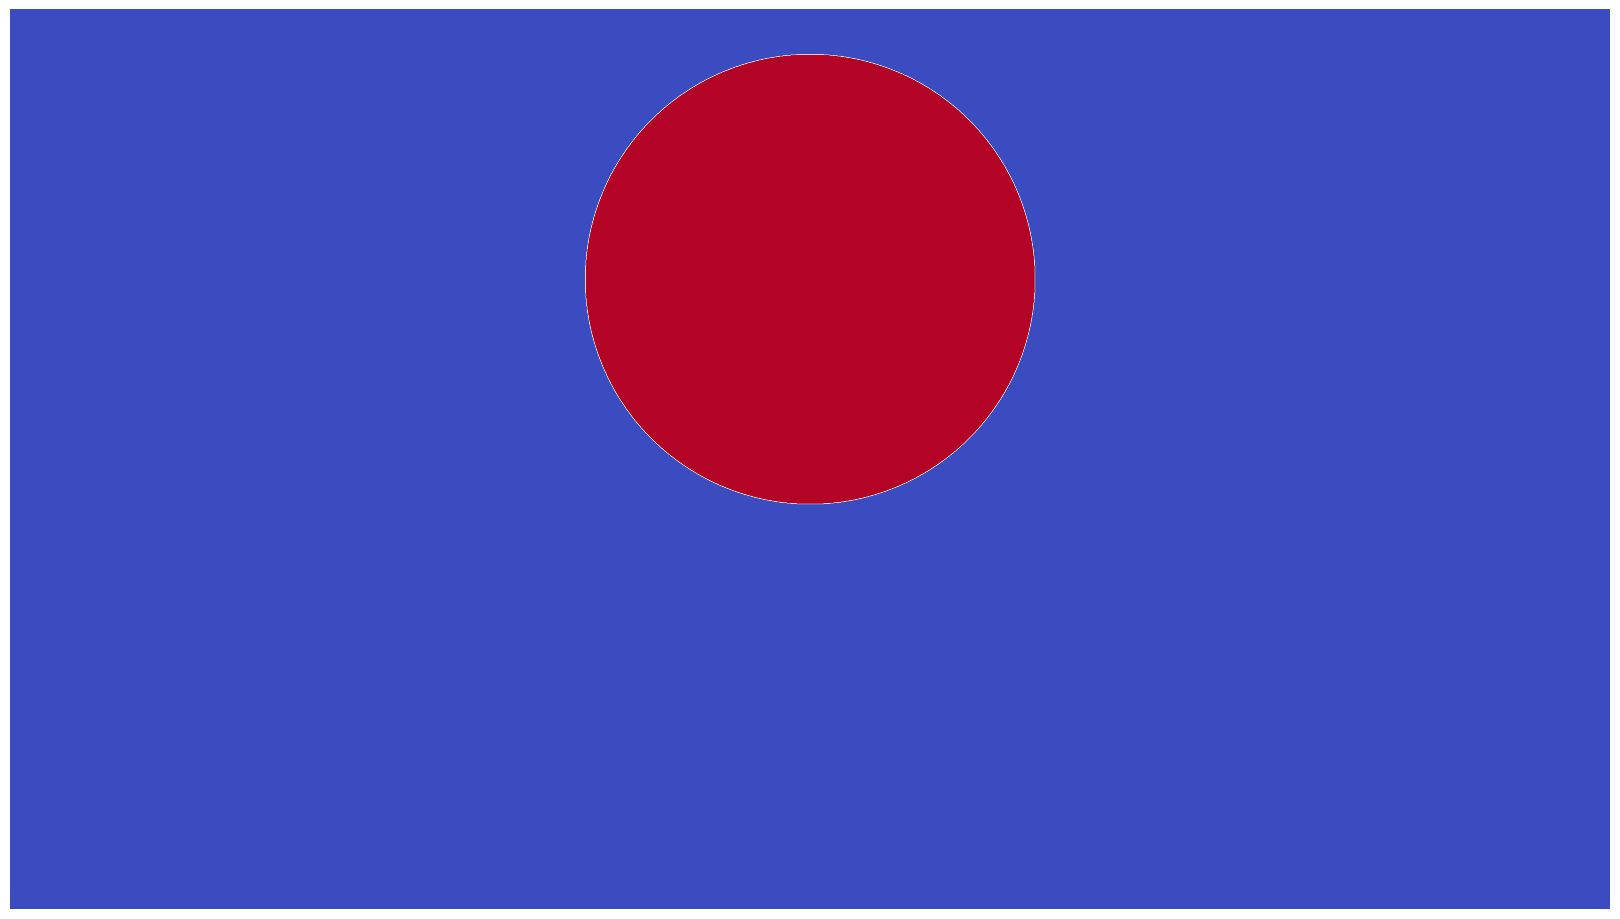

Initialization complete in: 0 hours, 0 minutes, 0.349 seconds.


In [5]:
## Initializing an instance of the NavierStokesSolver class.
s = t.time()

nss = NavierStokesSolver(radius_frac=0.5, n_rows=ROWS, n_cols=COLS, v_shift_frac=-0.2)
nss.plot()

e = t.time()
time_printer(st=s, en=e, op="initialization")

In [6]:
## Running nss.evolve().
s = t.time()

nss.evolve()

e = t.time()
time_printer(st=s, en=e, op="simulation")

Frame 90 / 9000 rendered; 1% complete: ∆t simulated so far = 2.58173 seconds.
Calculation and rendering (per frame) complete in: 0 hours, 0 minutes, 4.565 seconds.

Frame 180 / 9000 rendered; 2% complete: ∆t simulated so far = 3.62865 seconds.
Calculation and rendering (per frame) complete in: 0 hours, 0 minutes, 5.036 seconds.

Frame 270 / 9000 rendered; 3% complete: ∆t simulated so far = 4.45616 seconds.
Calculation and rendering (per frame) complete in: 0 hours, 0 minutes, 4.846 seconds.

Frame 360 / 9000 rendered; 4% complete: ∆t simulated so far = 5.10842 seconds.
Calculation and rendering (per frame) complete in: 0 hours, 0 minutes, 4.799 seconds.

Frame 450 / 9000 rendered; 5% complete: ∆t simulated so far = 5.67568 seconds.
Calculation and rendering (per frame) complete in: 0 hours, 0 minutes, 4.798 seconds.

Frame 540 / 9000 rendered; 6% complete: ∆t simulated so far = 6.17789 seconds.
Calculation and rendering (per frame) complete in: 0 hours, 0 minutes, 4.514 seconds.

Frame

# E.O.F.